# 05 — What was tried and did not work

A project that only reports what worked is not showing its working. This notebook
holds the two approaches that were planned, built, tested, and abandoned — with
the evidence that killed each one.

Both were dropped for the same reason: they were tested against something simpler
and lost.

1. **Product families from fabric names using text embeddings.** The plan was to
   normalise 2,401 free-text style names into families and benchmark rates within
   a family.
2. **SARIMA forecasting of monthly commission.** Carried over from the original
   version of this project, which used it to forecast twelve months ahead.


In [1]:
import sys
sys.path.append("../src")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import viz

viz.use_style()
pd.set_option("display.width", 200)

deals = pd.read_csv("../data/processed/deals_clean.csv", parse_dates=["contract_date"])
negotiated = deals[deals.product_division.isin(["knit", "garment"])]
print(f"{len(deals):,} clean deals, {len(negotiated):,} in the negotiated lines")

4,590 clean deals, 3,802 in the negotiated lines


---

# Part 1 — Product families from fabric names

## The idea, and why it looked good

The benchmark needs an idea of "comparable". Grouping by supplier works, but
fabric ought to matter too — a heavyweight denim and a light jersey are different
products and might carry different rates.

The style names looked promising. Here are the ones that inspired the plan:

```
3023, 10.75Oz, 59/60", 3/1 RHT, Cotton Poly
E-5124F-Blue, 10.5 Oz, 3/1 RHT, Rain Stretch, 55/56"
DS-9296 / AH-6620, 4/1 Satin, Black / Blue, 57", 80 C 19 P 1 E
```

Weight, width, weave, composition — real specifications, in free text. Embed
them, cluster them, and you have product families.

## Test 1 — How many style names actually look like that?


In [2]:
names = deals.style_name.astype(str)
unique_names = pd.Index(names.unique())

SPEC_PATTERNS = {
    "weight in oz": r"\d{1,2}(?:\.\d{1,2})?\s*oz",
    "width in inches": r"\d{2,3}\s*(?:/\s*\d{2,3})?\s*\"",
    "weave ratio (3/1, 4/1)": r"(?<!\d)[1-9]\s*/\s*[1-9](?!\d)\s*(?:RHT|LHT|S?twill|satin|sateen)",
    "construction term": r"\b(?:RHT|LHT|twill|satin|sateen|poplin|jersey|rib|fleece|canvas|dobby|oxford)\b",
    "fibre named": r"\b(?:cotton|poly|polyester|elastane|spandex|lycra|viscose|rayon|linen|modal|tencel)\b",
}
coverage = pd.DataFrame([
    {"pattern": label,
     "unique names": unique_names.str.contains(p, case=False, regex=True).sum(),
     "share of names": f"{unique_names.str.contains(p, case=False, regex=True).mean():.1%}"}
    for label, p in SPEC_PATTERNS.items()])

any_spec = unique_names.str.contains("|".join(SPEC_PATTERNS.values()), case=False, regex=True)
coverage.loc[len(coverage)] = {"pattern": "ANY of the above",
                               "unique names": any_spec.sum(),
                               "share of names": f"{any_spec.mean():.1%}"}
print(f"{len(unique_names):,} unique style names\n")
coverage

2,401 unique style names



,pattern,unique names,share of names
0,weight in oz,87,3.6%
1,width in inches,99,4.1%
2,"weave ratio (3/1, 4/1)",89,3.7%
3,construction term,63,2.6%
4,fibre named,12,0.5%
5,ANY of the above,121,5.0%


**Only 5.0% of style names contain any fabric specification at all.** The
examples that inspired the idea were the exception, not the rule.

The weave pattern needed care to get there. A naive `\d\s*/\s*\d` also matches
buyer codes like `2063808/15`, and the inflated figure it produces is worth
seeing, because it is the difference between abandoning this idea and pursuing
it.

In [3]:
naive = dict(SPEC_PATTERNS, **{"weave ratio (3/1, 4/1)": r"\d\s*/\s*\d"})
naive_any = unique_names.str.contains("|".join(naive.values()), case=False, regex=True)

pd.DataFrame([
    {"weave pattern": r"\d\s*/\s*\d  (naive)",
     "matched by weave alone": f"{unique_names.str.contains(naive['weave ratio (3/1, 4/1)'], regex=True).mean():.1%}",
     "any spec matched": f"{naive_any.mean():.1%}"},
    {"weave pattern": "ratio followed by a construction term  (used)",
     "matched by weave alone": f"{unique_names.str.contains(SPEC_PATTERNS['weave ratio (3/1, 4/1)'], case=False, regex=True).mean():.1%}",
     "any spec matched": f"{any_spec.mean():.1%}"},
])

,weave pattern,matched by weave alone,any spec matched
0,\d\s*/\s*\d (naive),21.8%,22.6%
1,ratio followed by a construction term (used),3.7%,5.0%


The careless version reports **22.6%** — four and a half times the true figure,
and enough to make this look like a promising direction. Requiring the ratio to be
followed by a construction term (`3/1 RHT`) removes the buyer codes.

Here is what the other 95% look like.

In [4]:
sample = pd.Series(unique_names[~any_spec]).sample(20, random_state=1).tolist()
for i in range(0, 20, 2):
    print(f"  {sample[i]:<34} {sample[i+1]}")

  203-0110B-08-001-1-                Dylan_27
  Short Regular_45                   Men's jogging pant
  D10608BC02343B3ST                  221-0117B-59-120-1-
  MEGAN_74                           2070175/4
  221-17B-26                         Slim Cropped Flare_145
  LIAM_39                            2034183/34
  Noah_3                             125486
  D10608BC02450C2                    MIRANDA_10
  DNM_H053                           Trouse with metal trims
  SYDNEY_001                         Loose_H161


These are buyer style codes (`2068727/0`, `IDS-5759 NC`), first-name style
programmes (`Tyler_143`, `AMY_49`, `Liam_215`), and plain garment descriptions
(`Boys trouser`, `Ladies Basic Jogger`). There is no shared technical vocabulary
to cluster on.

That alone is close to fatal, but "close to" is not "is". So we test it properly.

## Test 2 — Cluster them anyway and measure

Sentence-transformer models are trained on natural language, and these are mostly
product codes. Character n-gram TF-IDF is the better-matched tool for short
codes, so that is what we use.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

vectoriser = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, sublinear_tf=True)
matrix = vectoriser.fit_transform(unique_names.str.lower())
print(f"TF-IDF matrix: {matrix.shape[0]:,} names x {matrix.shape[1]:,} character n-grams\n")

baseline_variance = negotiated.commission_pct.var()

def variance_explained(labels_by_name):
    mapped = negotiated.style_name.astype(str).map(labels_by_name)
    group_median = negotiated.commission_pct.groupby(mapped).transform("median")
    return 1 - ((negotiated.commission_pct - group_median) ** 2).mean() / baseline_variance

rows = []
for k in [10, 25, 50, 100, 200]:
    model = KMeans(n_clusters=k, random_state=0, n_init=4).fit(matrix)
    labels = pd.Series(model.labels_, index=unique_names)
    rows.append({"clusters": k,
                 "silhouette": silhouette_score(matrix, model.labels_, sample_size=1500, random_state=0),
                 "rate variance explained": variance_explained(labels)})
clustering = pd.DataFrame(rows)
clustering.round(3)

TF-IDF matrix: 2,401 names x 7,618 character n-grams



,clusters,silhouette,rate variance explained
0,10,0.048,0.045
1,25,0.084,0.122
2,50,0.108,0.138
3,100,0.131,0.216
4,200,0.160,0.329


**Silhouette scores of 0.04 to 0.16.** Silhouette measures whether points sit
closer to their own cluster than to the next one; above roughly 0.5 means real
structure, and near zero means the boundaries are arbitrary. There are no natural
groups here.

The variance-explained column rises with k, but that is not evidence — with 200
clusters over 3,802 deals, any partition explains variance by memorising. The
question is what the clusters *are*.


In [6]:
model = KMeans(n_clusters=25, random_state=0, n_init=4).fit(matrix)
labels = pd.Series(model.labels_, index=unique_names)
for cluster in range(6):
    members = unique_names[labels.values == cluster]
    print(f"cluster {cluster:2d} (n={len(members):4d}):  " +
          ",  ".join(repr(m[:24]) for m in members[:5]))

cluster  0 (n= 449):  '3023, 10.75Oz, 59/60", 3',  'Az-5740, CPS, 8.75 Oz, 5',  'Az-6139, Bruton Fit, 7 O',  'IDS-1421HG, 9Oz, 59/60",',  'R-21597 FF (R-21264), 97'
cluster  1 (n=  46):  'Tyler_261',  'Tyler_262',  'Tyler_256',  'Tyler_252',  'Tyler_143'
cluster  2 (n=  34):  'STF-662, 21cX16X+70D/140',  'PSTF-41,98C 2sp, 3/1Stwi',  'Noah_6',  'Noah_3',  'PSTF-41(DIVINE),98C 2sp,'
cluster  3 (n=  38):  'Tie n Dye Short',  'Kids shorts',  'Mens shorts',  'Short Slim_10',  'Short Slim_3'
cluster  4 (n=  35):  'John_276',  'John_k313',  'John_k314',  'John_385',  'John_383'
cluster  5 (n=  37):  '2063808/15',  '2063808/14',  '2063808/5',  '2063808/4',  '2063815/0'


There is the answer. The clusters are not product families — they are **style
code prefixes**. One cluster is everything beginning `Tyler_`, another `John_`,
another `Harry `.

A style-code prefix belongs to one buyer. So the clustering was rediscovering the
customer, which is already a column in the dataset. It adds no information; it
just launders an existing column through a text model.

## Test 3 — The decisive comparison

Forget clusters. Extract the most favourable structure we can find by hand —
garment segment (men / ladies / kids) and garment type (trouser / jogger /
shirt) — and compare it against the plain columns we already have.


In [7]:
text = deals.style_name.astype(str).str.lower()

SEGMENT = {"men": r"\b(?:tkmen|men|mens|gents)\b", "ladies": r"\b(?:tklad|ladies|lady|women|womens)\b",
           "kids": r"\b(?:tkkid|kids|kid|child|children|baby|infant|junior)\b",
           "boys": r"\bboys?\b", "girls": r"\bgirls?\b"}
GARMENT = {"trouser/pant": r"\b(?:trouser|pant|pants|chino|cargo|jean|jeans)\b",
           "jogger/sweat": r"\b(?:jogger|sweat|sweatshirt|hoodie|fleece)\b",
           "shirt": r"\b(?:shirt|blouse|polo|tee|t-shirt|tshirt)\b",
           "jacket": r"\b(?:jacket|coat|blazer|parka|vest)\b",
           "dress/skirt": r"\b(?:dress|skirt|frock)\b", "short": r"\b(?:short|shorts|bermuda)\b",
           "knitwear": r"\b(?:knit|jersey|rib|pullover|cardigan)\b"}

def label_from_text(patterns):
    out = pd.Series("unknown", index=deals.index)
    for name, pattern in patterns.items():
        out[text.str.contains(pattern, regex=True, na=False) & out.eq("unknown")] = name
    return out

deals["segment"] = label_from_text(SEGMENT)
deals["garment_type"] = label_from_text(GARMENT)
scoped = deals.loc[negotiated.index]

def explained_by(column):
    group_median = scoped.commission_pct.groupby(scoped[column]).transform("median")
    return 1 - ((scoped.commission_pct - group_median) ** 2).mean() / baseline_variance

comparison = pd.DataFrame([
    {"grouping": f"{col}  (from style text)" if col in ("segment", "garment_type") else col,
     "source": "derived from style name" if col in ("segment", "garment_type") else "existing column",
     "groups": scoped[col].nunique(),
     "coverage": f"{scoped[col].ne('unknown').mean():.1%}" if col in ("segment", "garment_type") else "100.0%",
     "rate variance explained": explained_by(col)}
    for col in ["segment", "garment_type", "customer", "supplier", "customer_brand"]])
comparison.sort_values("rate variance explained", ascending=False).round(3)

,grouping,source,groups,coverage,rate variance explained
3,supplier,existing column,82,100.0%,0.318
2,customer,existing column,50,100.0%,0.310
4,customer_brand,existing column,46,100.0%,0.271
1,garment_type (from style text),derived from style name,7,6.2%,0.024
0,segment (from style text),derived from style name,6,23.8%,-0.092


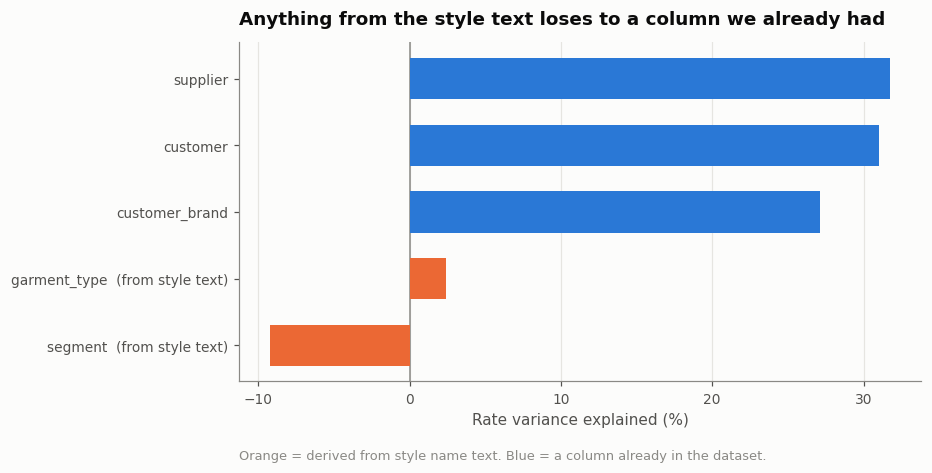

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ordered = comparison.sort_values("rate variance explained")
colors = [viz.SERIES[1] if s.startswith("derived") else viz.SERIES[0] for s in ordered.source]
ax.barh(range(len(ordered)), ordered["rate variance explained"] * 100, color=colors,
        height=0.62, zorder=3)
ax.axvline(0, color=viz.INK_MUTED, lw=1)
ax.set_yticks(range(len(ordered)), ordered.grouping)
ax.set_xlabel("Rate variance explained (%)")
ax.set_title("Anything from the style text loses to a column we already had")
viz.caption(ax, "Orange = derived from style name text. Blue = a column already in the dataset.")
viz.grid(ax, axis="x")
plt.show()

**Garment segment explains less than nothing** — a negative figure means
grouping by it predicts worse than using the overall median. Garment type manages
2.4%, and only covers 6% of deals.

The plain `supplier` column explains **31.8%**. One column, already in the file,
no text processing at all.

## Verdict on Part 1

Dropped. The evidence:

- 5.0% of style names contain a fabric specification
- Clustering produces silhouette scores of 0.04-0.16, meaning no real structure
- The clusters that do form are buyer code prefixes, duplicating the customer column
- The best hand-built feature from the text explains 2.4% of rate variance
  against `supplier`'s 31.8%

The idea was reasonable when it was proposed. It was proposed from five example
names, and the other 2,396 did not cooperate. Testing it cost an afternoon;
shipping it would have added an embedding model, a vector index, and a clustering
step to the pipeline in exchange for nothing.

---

# Part 2 — SARIMA forecasting

## What the original project did

The earlier version of this project fitted a SARIMA model to monthly commission
and forecast twelve months ahead. Its output included these:

```
2025-10:  -$29,854
2025-11:  -$20,731
2026-03:  -$13,193
2026-04:  -$28,516
```

Four months of negative commission. A sourcing agent cannot earn a negative
commission — that run was producing values the business cannot take.

We could not reproduce the negative values on our cleaned series, so we do not
claim SARIMA always does this; the original was fitted to a differently prepared
dataset. What matters is that an impossible output was published without anyone
noticing, and that no backtest was ever run. The backtest is the real test, so we
run it now.

## The test the original skipped


In [9]:
monthly = deals.set_index("contract_date").commission_usd.resample("MS").sum()
monthly = monthly[:"2025-03"]          # drop the partial final month
horizon = 12
history, actual = monthly[:-horizon], monthly[-horizon:]
print(f"{len(monthly)} monthly observations; holding out the last {horizon}")

70 monthly observations; holding out the last 12


In [10]:
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings("ignore")

forecasts = {
    "Naive: repeat last month": np.full(horizon, history.iloc[-1]),
    "Seasonal naive: same month last year": history[-12:].to_numpy(),
    "Mean of the last 12 months": np.full(horizon, history[-12:].mean()),
    "SARIMA(1,1,1)(1,1,1,12)":
        SARIMAX(history, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False).forecast(horizon).to_numpy(),
    "Holt-Winters (additive)":
        ExponentialSmoothing(history, trend="add", seasonal="add", seasonal_periods=12).fit().forecast(horizon).to_numpy(),
}
scoreboard = pd.DataFrame([
    {"method": name, "MAE ($)": mean_absolute_error(actual, values),
     "months forecast negative": int((values < 0).sum())}
    for name, values in forecasts.items()]).sort_values("MAE ($)")
scoreboard.round(0)

,method,MAE ($),months forecast negative
0,Naive: repeat last month,59732.0,0
3,"SARIMA(1,1,1)(1,1,1,12)",63593.0,0
2,Mean of the last 12 months,73027.0,0
1,Seasonal naive: same month last year,75744.0,0
4,Holt-Winters (additive),81167.0,0


**SARIMA loses to repeating last month's number.**

The naive forecast — "next month will be like this month" — gets MAE \$59,732.
SARIMA gets \$63,593, about 6% worse. Holt-Winters is worse still at \$81,167.
Every sophisticated method here is beaten by the crudest one available.

On our cleaned series none of the methods forecast negative values, so the
original's negative months came from its own data preparation rather than from
SARIMA as such. The ranking is the finding, and the ranking is unambiguous.

## Why it fails

The series has 70 monthly observations. A seasonal model with a 12-month period
needs to estimate a full annual pattern, which means it has fewer than six
complete cycles to learn from — while the business itself changed underneath it,
losing half its volume over the same window.


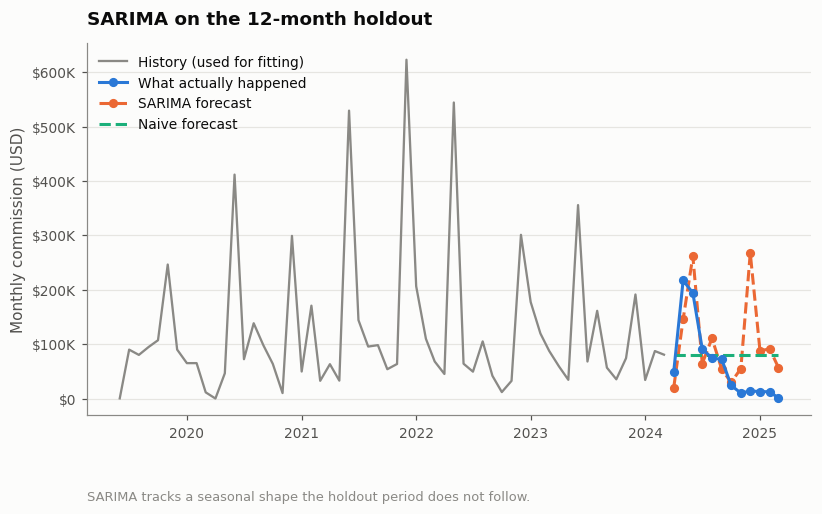

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(history.index, history.values, color=viz.INK_MUTED, lw=1.5,
        label="History (used for fitting)", zorder=3)
ax.plot(actual.index, actual.values, color=viz.SERIES[0], marker="o", ms=5,
        label="What actually happened", zorder=5)
ax.plot(actual.index, forecasts["SARIMA(1,1,1)(1,1,1,12)"], color=viz.SERIES[1],
        marker="o", ms=5, ls="--", label="SARIMA forecast", zorder=4)
ax.plot(actual.index, forecasts["Naive: repeat last month"], color=viz.SERIES[2],
        ls="--", label="Naive forecast", zorder=4)
ax.set_ylabel("Monthly commission (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.money))
ax.set_title("SARIMA on the 12-month holdout")
ax.legend(loc="upper left")
viz.grid(ax)
viz.caption(ax, "SARIMA tracks a seasonal shape the holdout period does not follow.")
plt.show()

## Verdict on Part 2

Dropped. Not because time series analysis is wrong for this data in principle,
but because on this series, at this length, it loses to a one-line rule and
produces impossible values.

The descriptive parts of the original time series work — the seasonal
decomposition, the ADF and KPSS stationarity tests, the ACF and PACF plots — were
methodologically sound and are worth keeping as description. It is the forecast,
and the strategic recommendations built on it, that do not survive a backtest.

---

# What both of these have in common

Neither idea was unreasonable. One came from reading five example rows; the other
from a standard toolkit applied without asking whether the series could support
it. Both were killed the same way: **build the simple alternative first, and make
the sophisticated method beat it.**

- Text clustering had to beat `supplier`. It did not.
- SARIMA had to beat "same as last month". It did not.

That comparison costs very little and it is the difference between a project that
knows what it is worth and one that does not.
